In [39]:
from pathlib import Path

import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

In [40]:
ox.settings.all_oneway = True

In [41]:
PLACE_NAME = "O'Hare, Chicago, Illinois, USA"
DATA_BASE_PATH = Path("./data").resolve().absolute()

In [42]:
gdf = ox.geocode_to_gdf(PLACE_NAME)
gdf = gdf.to_crs(epsg=4326)  # Ensure it's in WGS84 latitude/longitude
gdf.head()

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((-87.94009 42.0008, -87.94003 41.9981...",-87.940088,41.937286,-87.834793,42.0089,344717769,relation,7745358,41.975164,-87.844242,boundary,administrative,20,0.369336,suburb,O'Hare,"O'Hare, Chicago, Jefferson Township, Cook Coun..."


In [43]:
gdf.to_file(DATA_BASE_PATH / "ohare.geojson", driver="GeoJSON")

<Axes: >

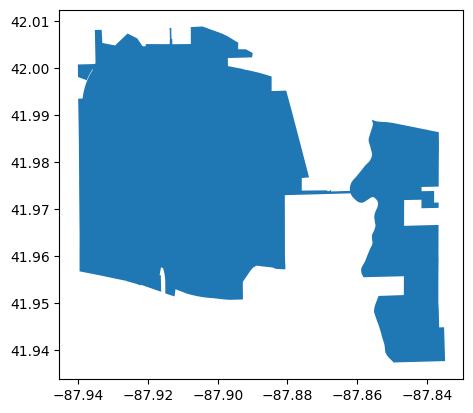

In [44]:
gdf.plot()

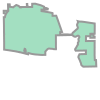

In [45]:
polygon = gdf.geometry.iloc[0]
polygon

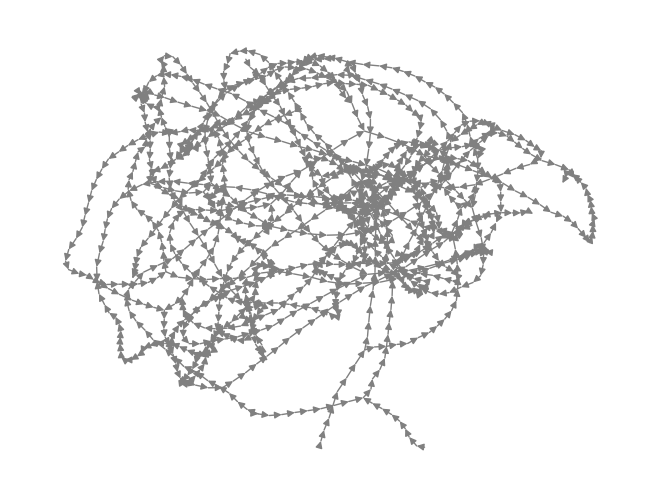

In [46]:
G = ox.graph_from_polygon(polygon, simplify=False, network_type="drive")
nx.draw(G, node_size=0, edge_color="gray")
plt.show()

In [48]:
ox.io.save_graph_xml(G, filepath=DATA_BASE_PATH / "ohare_network.osm.xml")